----
# **<span style="color:SEAGREEN">PROYECTO MACHINE LEARNING ESTUDIANTES</span>**
# **<span style="color:SEAGREEN">Modelo de clasificación</span>**
----

---
---
## <span style="color:gray">**Importación de librerías**</span> 📂

In [1]:
# Data processing
# -----------------------------------------------------------------------
import pandas as pd

# Visualization  
# -----------------------------------------------------------------------
import seaborn as sns
import matplotlib.pyplot as plt

# Model selection and evaluation  
# -----------------------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

# Regression models  
# -----------------------------------------------------------------------
from sklearn.linear_model import LogisticRegression

# Metrics  
# -----------------------------------------------------------------------
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

---
---
## <span style="color:gray">**Carga de datos**</span> 📥

In [2]:
# Configuración de Pandas
# -----------------------------------------------------------------------
pd.set_option('display.max_columns', None)  # Para visualizar todas las columnas de los DataFrames

In [3]:
df = pd.read_csv("../data/output/df_clasificacion.csv", index_col=0)
df.head()

,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad,nivel_dificultad,aprobado,tiene_tutor_No,tiene_tutor_Sí,horario_estudio_preferido_Desconocido,horario_estudio_preferido_Mañana,horario_estudio_preferido_Noche,horario_estudio_preferido_Tarde,estilo_aprendizaje_Auditivo,estilo_aprendizaje_Desconocido,estilo_aprendizaje_Kinestésico,estilo_aprendizaje_Lectura/Escritura,estilo_aprendizaje_Visual
0,8.957476,48.830601,86.640182,6.675694,25,0.0,1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,11.042524,80.825707,83.449655,4.616844,18,2.0,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,4.510776,90.383694,74.623607,7.755246,25,0.0,1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,6.647213,81.878257,82.849841,8.592826,23,0.0,1,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1.000000,66.254179,54.539935,6.671840,21,1.0,1,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


---
---
## <span style="color:gray">**Modelo de clasificación**</span> 🤖
---

### Separación del conjunto de datos

In [4]:
# Variable objetivo
tv = 'aprobado'

# Definimos las variables predictoras (X) y la variable objetivo (y)
X = df.drop(columns=[tv])  # Características
y = df[tv]  # Etiqueta o resultado

In [5]:
# Dividimos los datos en 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Mostramos los tamaños de los conjuntos resultantes
print(f"Tamaño del conjunto de entrenamiento: {X_train.shape}")
print(f"Tamaño del conjunto de prueba: {X_test.shape}")

Tamaño del conjunto de entrenamiento: (800, 17)
Tamaño del conjunto de prueba: (200, 17)


---

### Escalar

In [6]:

# Creamos el RobustScaler
scaler = RobustScaler()

# Seleccionamos las columnas numéricas continuas
columnas_a_escalar = ['horas_estudio_semanal', 'tasa_asistencia', 'nota_anterior', 'horas_sueno', 'edad']

# Ajustamos y escalamos
X_train[columnas_a_escalar] = scaler.fit_transform(X_train[columnas_a_escalar])
X_test[columnas_a_escalar] = scaler.transform(X_test[columnas_a_escalar])


---

## Regresión Logística

### Entrenamiento del modelo

In [7]:
# Crear una instancia de LogisticRegression
model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)

# Ajustar el modelo con los datos de entrenamiento
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [8]:
# Hacer predicciones con los datos de prueba
y_pred = model.predict(X_test)

In [9]:
# Obtener probabilidades de predicción
y_prob = model.predict_proba(X_test)[:, 1]  # Probabilidad de la clase positiva

---

### Validación del modelo

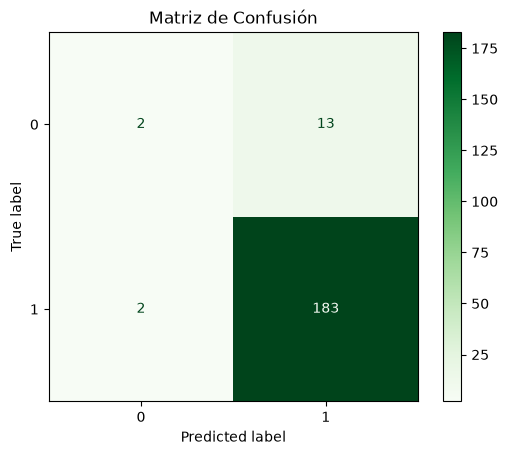

In [10]:
# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Visualizar la matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Greens")
plt.title("Matriz de Confusión")
plt.show()

La matriz de confusión nos permite evaluar con exactitud en qué acertó el modelo y en qué tipo de errores cayó al clasificar a los estudiantes del conjunto de prueba (Test) entre suspensos (`0`) y aprobados (`1`):

- Verdaderos Negativos (2): De los 15 estudiantes que realmente suspendieron el curso, el modelo solo logró identificar correctamente a 2 de ellos.

- Verdaderos Positivos (183): De los 185 estudiantes que realmente aprobaron el curso, el modelo clasificó correctamente a 183 de ellos. 

- Falsos Negativos (2): Hubo 2 estudiantes que en la vida real sí aprobaron el curso, pero el modelo predijo por error que iban a suspender.

- Falsos Positivos (13):Hubo 13 estudiantes que en la vida real suspendieron, pero el modelo los clasificó erróneamente como aprobados.

Esta matriz refleja un desbalanceo de clases (el dataset tiene muchísimos más aprobados que suspensos). 

Debido a esto, la Regresión Logística tomó una postura muy conservadora: tiende a predecir casi siempre que el alumno va a aprobar (`1`). Al hacerlo, asegura una cantidad masiva de aciertos en los aprobados (183), pero se vuelve muy poco eficaz para detectar a los alumnos que no pasan la materia, dejando pasar a 13 estudiantes que no superan la materia como si fueran a aprobar (Falsos Positivos) y acertando únicamente 2. 


---

### Métricas

In [11]:
# Calcular predicciones para el conjunto de entrenamiento y prueba
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Obtener las probabilidades de predicción
y_train_proba = model.predict_proba(X_train)
y_test_proba = model.predict_proba(X_test)

In [12]:
# Cálculo de métricas
metrics = {
    "train": {
        "Accuracy": accuracy_score(y_train, y_train_pred),
        "Precision": precision_score(y_train, y_train_pred),
        "Recall": recall_score(y_train, y_train_pred),
        "F1-score": f1_score(y_train, y_train_pred),
    },
    "test": {
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "Precision": precision_score(y_test, y_test_pred),
        "Recall": recall_score(y_test, y_test_pred),
        "F1-score": f1_score(y_test, y_test_pred),
    },
}

# Mostrar métricas en un DataFrame
df_metrics = pd.DataFrame(metrics).T

In [13]:
df_metrics.round(2)

,Accuracy,Precision,Recall,F1-score
train,0.90,0.90,0.99,0.94
test,0.92,0.93,0.99,0.96


- Accuracy (Exactitud): A nivel general, el modelo acierta en el 92% de todas sus predicciones en datos nuevos. La cercanía entre ambos números (train y test) demuestra que el modelo es altamente estable y no sufre de sobreajuste (overfitting).

- Precision (Precisión): Esta métrica nos dice qué tan confiable es el modelo cuando asegura que un estudiante va a aprobar. Un 93% significa que de cada 100 alumnos que el modelo etiqueta como "Aprobados", 93 realmente lo hacen, mientras que 7 corresponden a alumnos que en realidad suspendieron (los Falsos Positivos).

- Recall (Sensibilidad): El modelo es excepcionalmente eficaz para encontrar a los alumnos que van a pasar la materia; casi ningún estudiante aprobado se le escapa al algoritmo.

- F1-Score: Confirma un rendimiento general robusto y muy equilibrado para la predicción de la clase mayoritaria.

Aunque un Accuracy del 92% y un F1-Score del 96% parecen excelentes a primera vista, estas métricas están infladas por el desbalanceo de los datos (la enorme cantidad de aprobados frente a los pocos suspenso). 

Como vimos en la Matriz de Confusión, el modelo logra ese 99% de Recall porque fue a lo seguro y predijo como "Aprobado" para casi todos los alumnos. Esto hace que las métricas generales luzcan casi perfectas, pero oculta el hecho de que el modelo es muy deficiente detectando a los alumnos que realmente no pasan el curso (de los cuales se le escaparon 13 de 15). Para corregir este sesgo analítico, se vamos a implementar el cálculo ponderado.

In [14]:
# Cálculo de métricas con desbalanceo
metrics_weighted = {
    "train": {
        "Accuracy": accuracy_score(y_train, y_train_pred),
        "Precision": precision_score(y_train, y_train_pred, average="weighted"),
        "Recall": recall_score(y_train, y_train_pred, average="weighted"),
        "F1-score": f1_score(y_train, y_train_pred, average="weighted"),
    },
    "test": {
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "Precision": precision_score(y_test, y_test_pred, average="weighted"),
        "Recall": recall_score(y_test, y_test_pred, average="weighted"),
        "F1-score": f1_score(y_test, y_test_pred, average="weighted"),
    },
}

# Mostrar métricas en un DataFrame
df_metrics_weighted = pd.DataFrame(metrics_weighted).T

In [15]:
df_metrics_weighted.round(2)

,Accuracy,Precision,Recall,F1-score
train,0.90,0.87,0.90,0.86
test,0.92,0.90,0.92,0.90


Al recalcular las métricas globales utilizando el promedio ponderado, ajustamos el análisis para que los resultados reflejen con total honestidad el desbalanceo real de las clases en nuestro conjunto de datos:

- F1-Score Ponderado:  Un 0.90 en el conjunto de prueba demuestra que el modelo mantiene un rendimiento general muy robusto. El hecho de que la métrica de prueba sea ligeramente mejor que la de entrenamiento confirma que el algoritmo no sufre de sobreajuste (overfitting) y que generaliza de forma correcta.

- Precision Ponderada: Al tomar en cuenta el tamaño de ambas clases, nos dice que cuando el modelo genera predicciones, tiene un 90% de fiabilidad en promedio. Reduce el sesgo optimista que provocaba medir únicamente la clase mayoritaria.

- Recall Ponderado: Indica que el algoritmo es capaz de capturar correctamente al 92% de los estudiantes del dataset, balanceando el peso masivo de los aprobados con la baja frecuencia de los alumnos suspensos.

La bajada matemática demuestra que el promedio ponderado está haciendo su trabajo ya que ha obligado al modelo a incluir el peso de los 13 alumnos suspensos que no se logró detectar en la matriz de confusión. El modelo definitivo entrega un 92% de exactitud equilibrada, lo cual constituye un resultado sólido y transparente.


---

### Importancia de características

In [16]:
# Crear DataFrame con los coeficientes
coef_df = pd.DataFrame({'Feature': X.columns.to_list(), 'Coefficient': model.coef_[0]})
coef_df = coef_df.sort_values(by='Coefficient', ascending=False, key=abs)  # Ordenar por magnitud

In [17]:
coef_df.sort_values(by='Coefficient', ascending=False, key=abs)

,Feature,Coefficient
0,horas_estudio_semanal,1.221148
1,nota_anterior,0.817711
8,horario_estudio_preferido_Desconocido,0.757829
5,nivel_dificultad,-0.553353
2,tasa_asistencia,0.509812
10,horario_estudio_preferido_Noche,-0.427067
15,estilo_aprendizaje_Lectura/Escritura,0.300579
16,estilo_aprendizaje_Visual,-0.217306
11,horario_estudio_preferido_Tarde,-0.206714
9,horario_estudio_preferido_Mañana,-0.125880


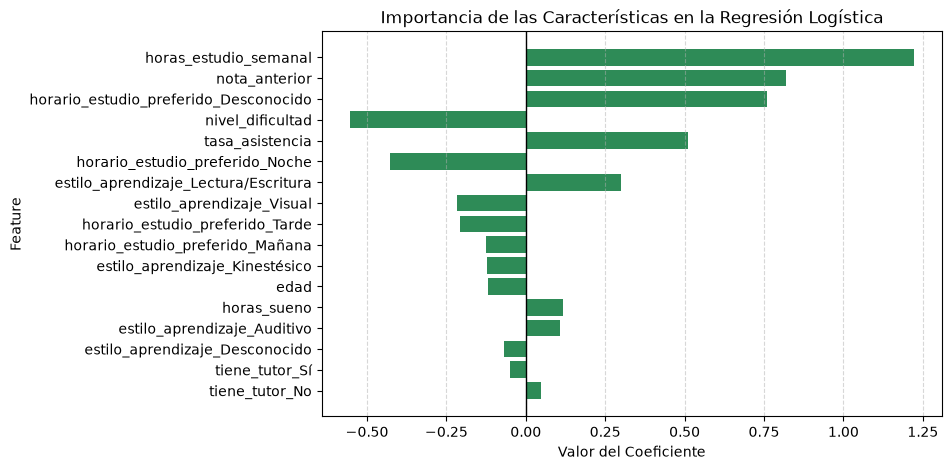

In [18]:
# Visualizar los coeficientes en un gráfico de barras
plt.figure(figsize=(8, 5))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color='seagreen')
plt.xlabel("Valor del Coeficiente")
plt.ylabel("Feature")
plt.title("Importancia de las Características en la Regresión Logística")
plt.axvline(0, color='black', linewidth=1)  # Línea en el 0 para referencia
plt.grid(axis='x', linestyle='--', alpha=0.5) # Líneas de cuadrícula verticales
plt.gca().invert_yaxis()  # Invertir eje para que la más importante esté arriba
plt.show()


- Los mayores impulsores de éxito para los estudiantes:
    
    - `horas_estudio_semanal`: es la barra positiva más larga de todas. Nos indica que dedicarle horas al estudio es el factor individual más poderoso para asegurar que un alumno apruebe el curso.

    - `nota_anterior` y tener un `horario_estudio_preferido_Desconocido` también son fuertes predictores de aprobado.

    - `tasa_asistencia` tiene un peso positivo importante de 0.50, demostrando que asistir a clases contribuye directamente a mantenerse en la zona de aprobados.

- Factores que aumentan el riesgo de suspenso:

    - `nivel_dificultad`** es el factor negativo más grande. A mayor dificultad del curso, disminuyen fuertemente las probabilidades de aprobar.

    - `horario_estudio_preferido_Noche` también presenta un impacto negativo notable, lo que sugiere que los estudiantes que estudian de noche tienen una mayor tendencia estadística a suspender en este modelo.

- Estilos de aprendizaje:
    
    - El estilo de aprendizaje `Lectura/Escritura` ayuda a subir la probabilidad de aprobar , mientras que el estilo `Visual` disminuye la probabilidad.

- Variables con peso casi nulo:
    
    - Características como la `edad`, las `horas_sueno`, el estilo `Auditivo` y `tiene_tutor` tienen barras muy pequeñas o casi pegadas al cero, lo que significa que aportan muy poca información al modelo para decidir si un alumno aprueba o no.

---
### Entrenamiento final

In [19]:
import joblib

# Entrenar el modelo con todo el conjunto de datos
model_final = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
model_final.fit(X, y)

# Guardar el modelo entrenado para producción
joblib.dump(model_final, "../models/modelo_clasificacion.pkl")

['../models/modelo_clasificacion.pkl']